In [3]:
library(dplyr)
library(ggplot2)
library(data.table)

source("/mnt/lareaulab/reliscu/code/ggplot_theme.R")

source("/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/code/top_corr_module_fxns.R")

theme_set(default_theme())
options(repr.matrix.max.cols=Inf) 

In [4]:
setwd("/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/MOp")

Goal: verify enriched modules actually represent a given cell type by plotting cell type abundance vs. the module eigengene

In [5]:
# These should match the settings used to get enrichment results in previous step

mod_def <- "PosBC"
unique <- FALSE 

In [6]:
pairwise_res_list <- readRDS("data/DE_genes/yao_2021_MOp_STAR_donor_subclass_label_pseudobulk_pairwise_DE_genes_dream.RDS")
pairwise_ctype_genes <- prep_DE_genes(pairwise_res_list, pairwise=TRUE, unique=unique)

In [47]:
names(pairwise_ctype_genes) <- unlist(sapply(names(pairwise_ctype_genes), function(x) gsub(" ", "_", x)))

## Round 1 (SD = 25, mergeParam = 0.85)

In [ ]:
network_dir <- "yao_2021_MOp_STAR_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_Modules"
pseudobulk_legend <- read.csv("data/SyntheticDatasets/SyntheticDataset1_20pcntCells_25SD_200samples_legend_11-19-35.csv")
top_qval_mods_df <- read.csv("data/enrichments/yao_2021_MOp_pairwise_DE_genes_dream_uniqueFALSE_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_PosBC_top_Qval_modules.csv")

In [ ]:
pseudobulk_legend$Cell.type <- sapply(pseudobulk_legend$Cell.type, function(x) gsub(" ", "_", x))
pseudobulk_legend$Cell.type <- sapply(pseudobulk_legend$Cell.type, function(x) gsub("/", "_", x, fixed=TRUE))

In [10]:
ctype_genes_list <- pairwise_ctype_genes

top_corr_mods_df <- get_top_corr_mods(network_dir, pseudobulk_legend, top_qval_mods_df, ctype_genes_list, mod_def)
top_corr_mods_df %>% arrange(Old_cor)

,Cell_type,Pseudobulk_SD,Cor,Old_cor,Pval,Old_pval,Module_genes,Old_module_genes,DE_genes,Module,Old_module,Network,Old_network,ME_path,Old_ME_path,kME_path,Old_kME_path
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
plum1,pvalb_GABAergic_cortical_interneuron,23.79,0.9153963,0.5088048,8.499013e-96,1.022042e-130,"Pvalb, Nog, Tac1, Nek7, Gm13629, Kcnc1, Syt2, Kcnc2, 6330411D24Rik, St3gal6, Eya4, Ank1, Cox6a2, Gpr83, Pacsin2","Uqcrh, Atp5mc3, Ndufa3, Ndufc1, Atp5pf, Atp5mf, Cox5a, Ndufb8, Cox5b, Cox7b, Cox7c, Gm26631, Ndufa6, Ndufv2, Uqcr10","Sncb, Slc38a1, Hspbp1, Fchsd1, Glrx5, Rell2, Nt5m, Sars1, Bend6, Got2, Slbp, Ndufaf5, Ppp1cc, Asns, Clec2l",plum1,black,Bicor-None_signum0.668_minSize4_merge_ME_0.85_20619,Bicor-None_signum0.668_minSize12_merge_ME_0.85_20619,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/MOp/yao_2021_MOp_STAR_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.668_minSize4_merge_ME_0.85_20619/Module_eigengenes_12-56-30.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/MOp/yao_2021_MOp_STAR_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.668_minSize12_merge_ME_0.85_20619/Module_eigengenes_01-02-12.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/MOp/yao_2021_MOp_STAR_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.668_minSize4_merge_ME_0.85_20619/kME_table_12-56-30.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/MOp/yao_2021_MOp_STAR_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.668_minSize12_merge_ME_0.85_20619/kME_table_01-02-12.csv
plum11,VIP_GABAergic_cortical_interneuron,25.23,0.9184509,0.7716659,1.638108e-70,4.683666e-99,"Igsf3, Tiam1, Grpr, Pthlh, Gpd1, Gm42538, Limch1, Calb2, Sall1, Penk, Crlf1, Slc18a3, Sostdc1, Ostf1, Srrm4","Vip, Igf1, Ap1s2, Gm17750, Prox1, Prox1os, Crh, Tac2, Asic4, Adra1b, Cxcl14, Vstm2l, Shisa8, Wnt5a, Gm37264","C1qtnf4, Arfgef3, Uchl4, Vstm2l, Ugcg, Castor2, Uchl3, Csmd3, Plvap, Cit, Sobp, Srrm4, Tiam1, Asic1, A330076H08Rik",plum1,tan,Bicor-None_signum0.114_minSize10_merge_ME_0.85_20619,Bicor-None_signum0.668_minSize6_merge_ME_0.85_20619,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/MOp/yao_2021_MOp_STAR_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.114_minSize10_merge_ME_0.85_20619/Module_eigengenes_03-29-52.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/MOp/yao_2021_MOp_STAR_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.668_minSize6_merge_ME_0.85_20619/Module_eigengenes_12-59-10.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/MOp/yao_2021_MOp_STAR_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.114_minSize10_merge_ME_0.85_20619/kME_table_03-29-52.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/MOp/yao_2021_MOp_STAR_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.668_minSize6_merge_ME_0.85_20619/kME_table_12-59-10.csv
plum12,L4_5_intratelencephalic_projecting_glutamatergic_neuron_of_the_primary_motor_cortex,28.50,0.8495230,0.8495230,1.113881e-52,2.561485e-71,"Krt12, A830036E02Rik, Dnajc21, Hspb3, Sac3d1, Grm2, Nrxn1, Dapk2, Adcyap1, Crhr1, Gtdc1, Gm29674, Adam33, Hgf, Rspo1","Krt12, A830036E02Rik, Dnajc21, Hspb3, Sac3d1, Grm2, Cpne9, Nrxn1, Dapk2, Adcyap1, Crhr1, Gm10493, Gtdc1, Gm29674, Adam33","Ly6e, Stx1a, Gabrg2, Syt13, A230004M16Rik, Stxbp1, Nrsn1, Nudt4, Dnajc21, B4galt2, Gm4204, Krt12, A830036E02Rik, Grm2, Tnnc1",plum1,violet,Bicor-None_signum0.261_minSize10_merge_ME_0.85_20619,Bicor-None_signum0.261_minSize15_merge_ME_0.85_20619,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/MOp/yao_2021_

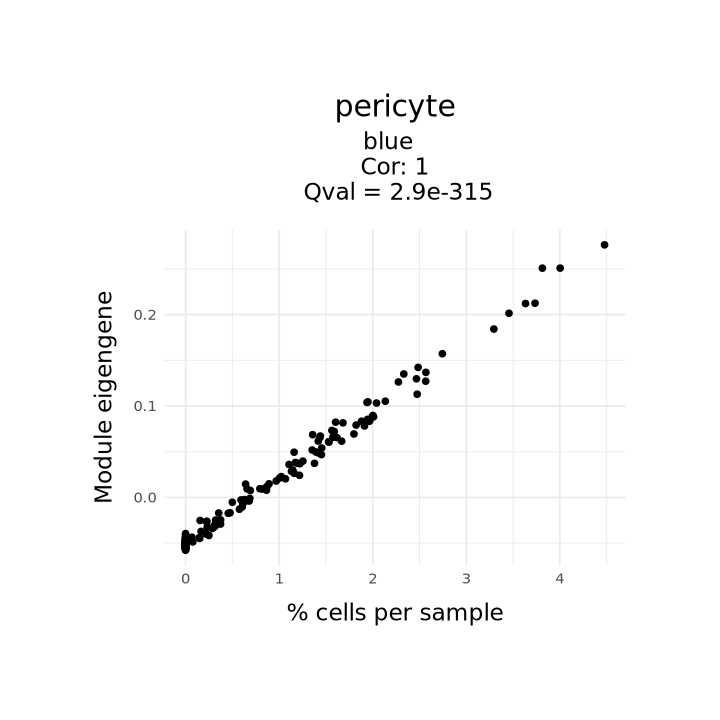

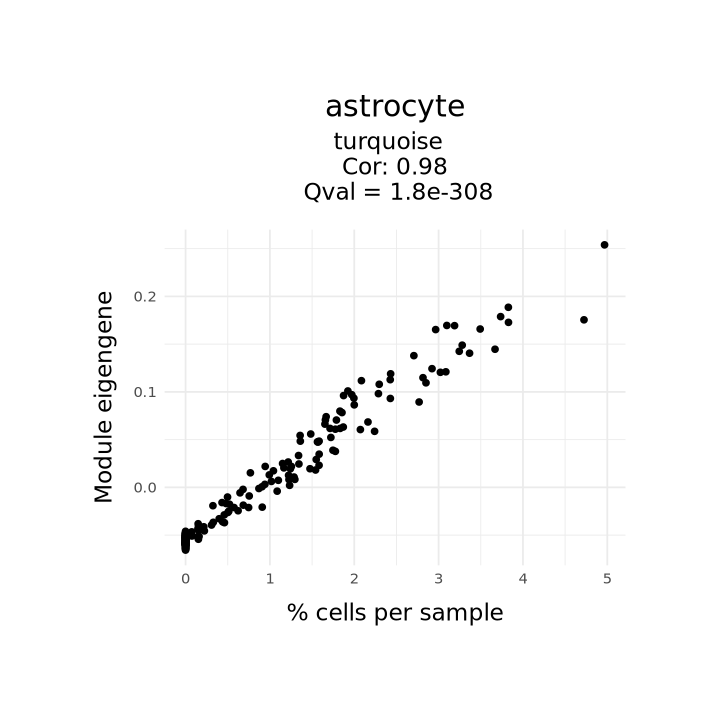

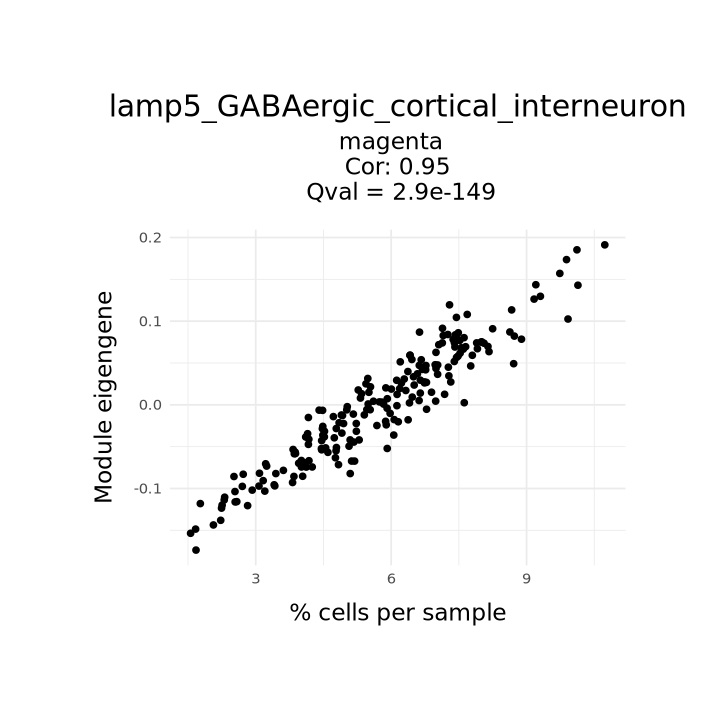

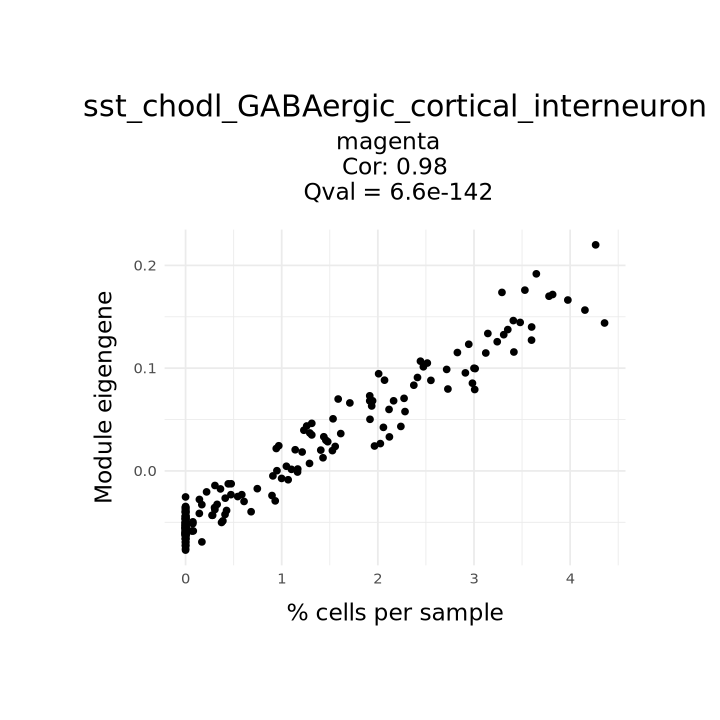

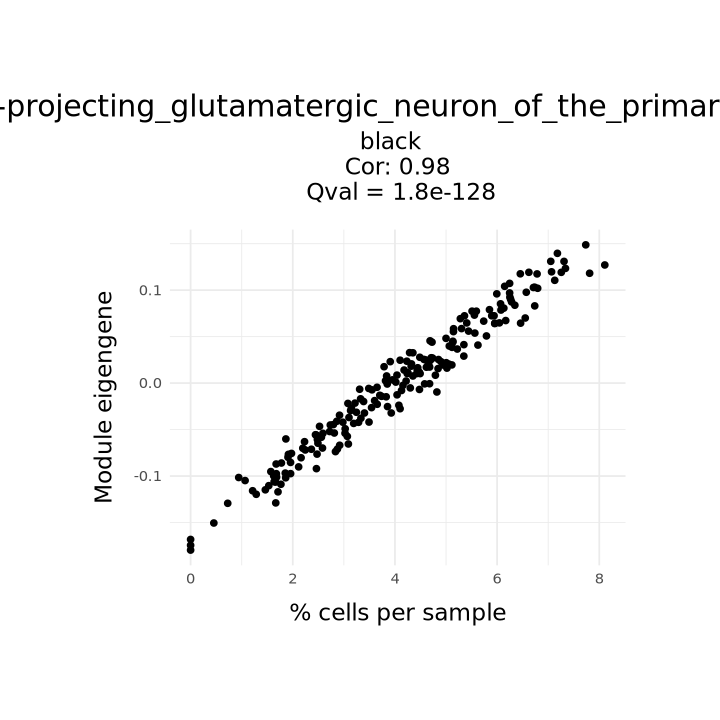

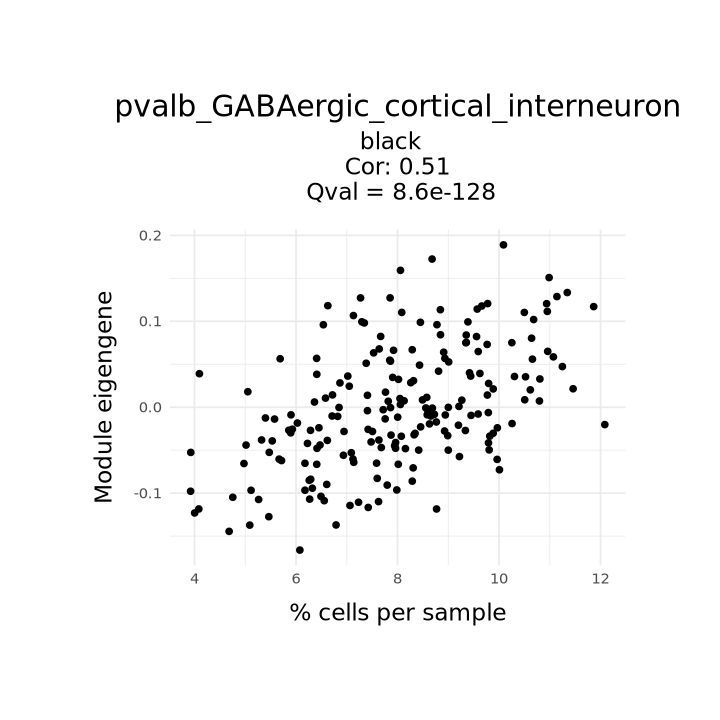

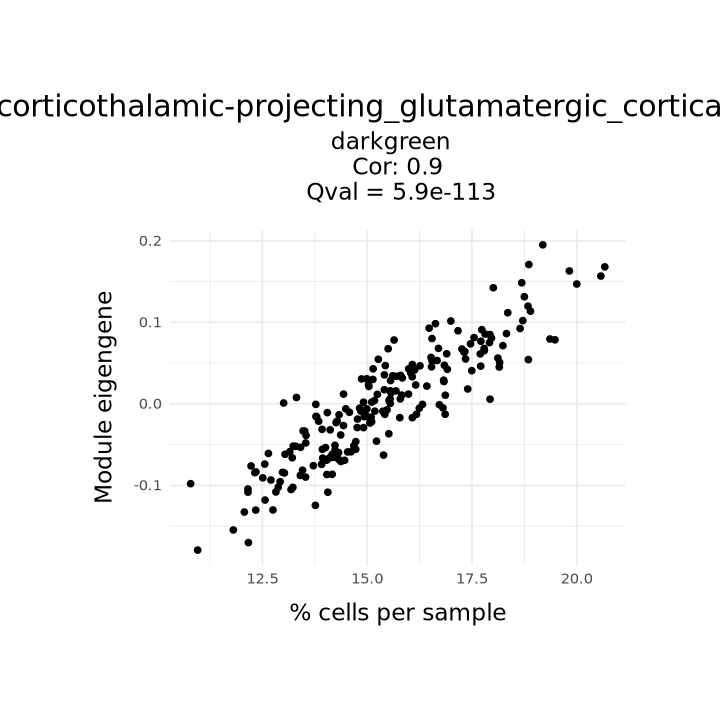

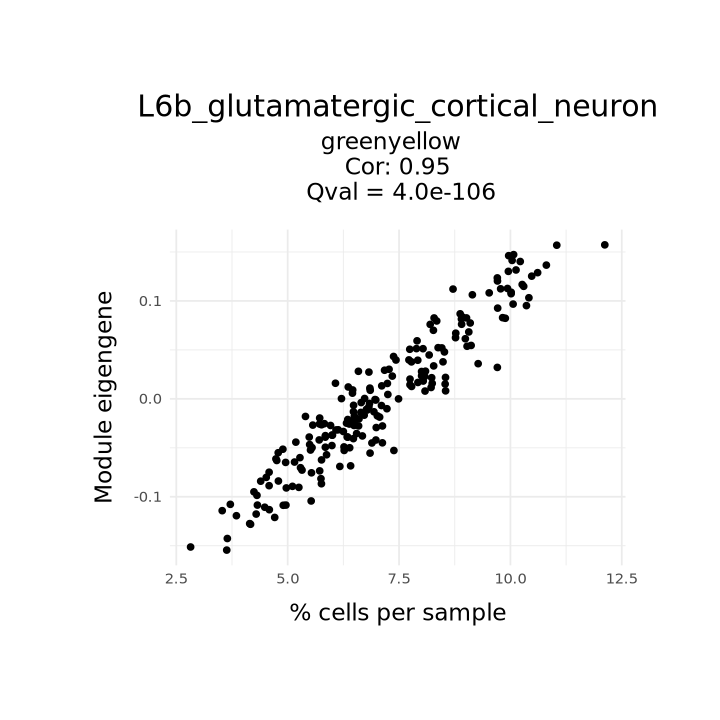

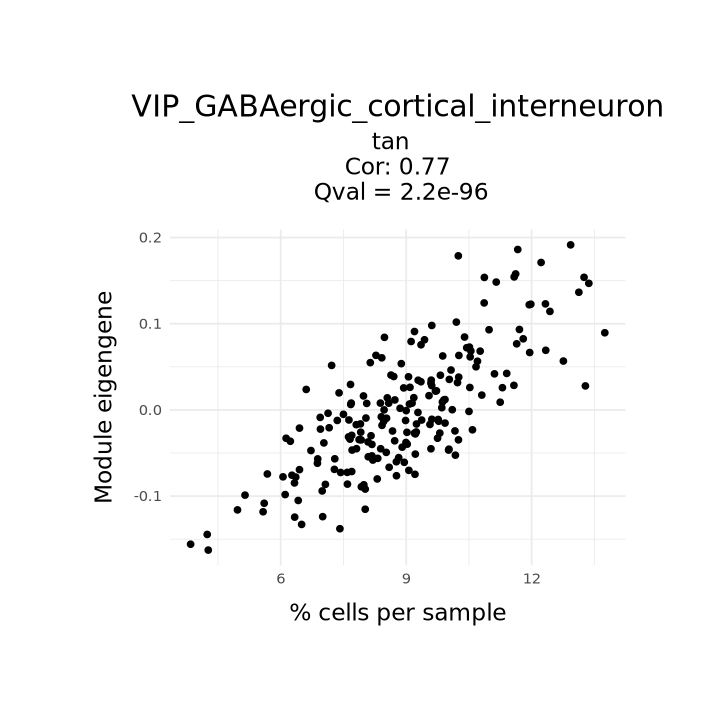

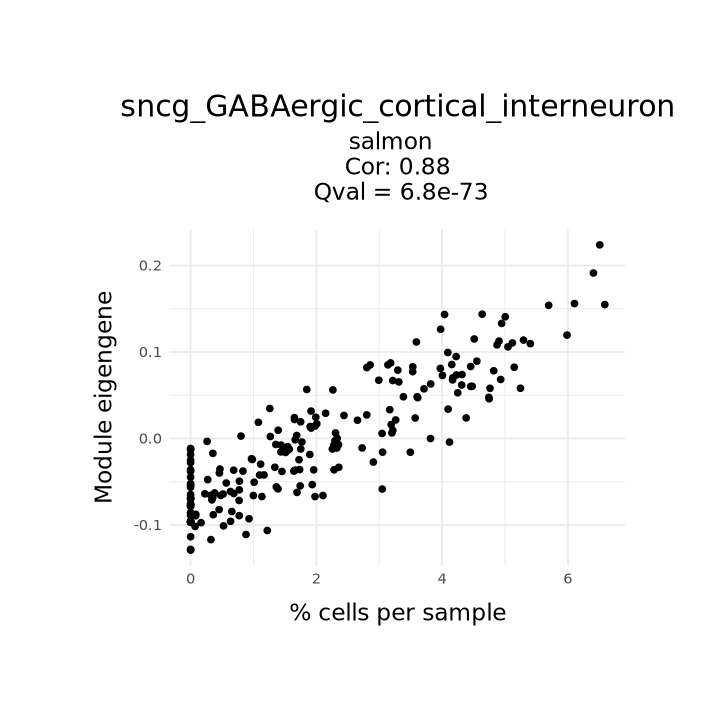

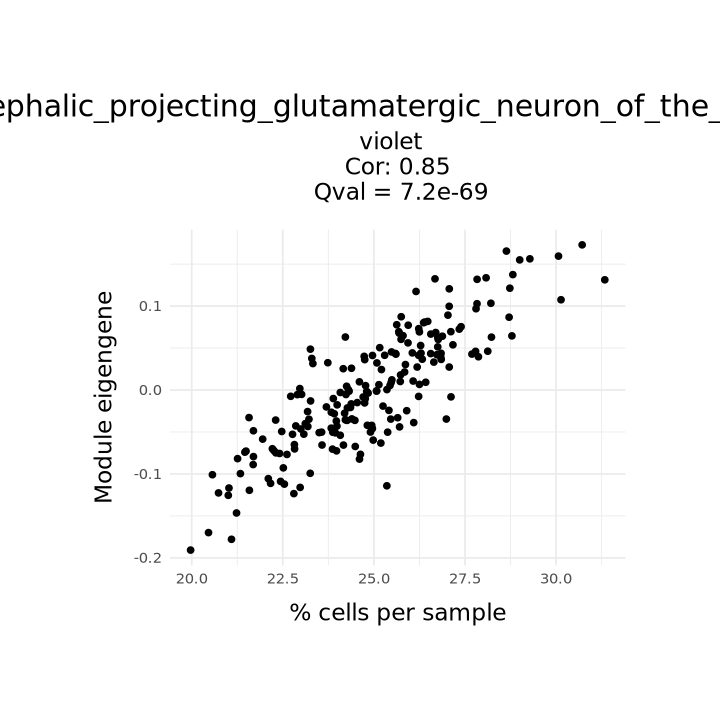

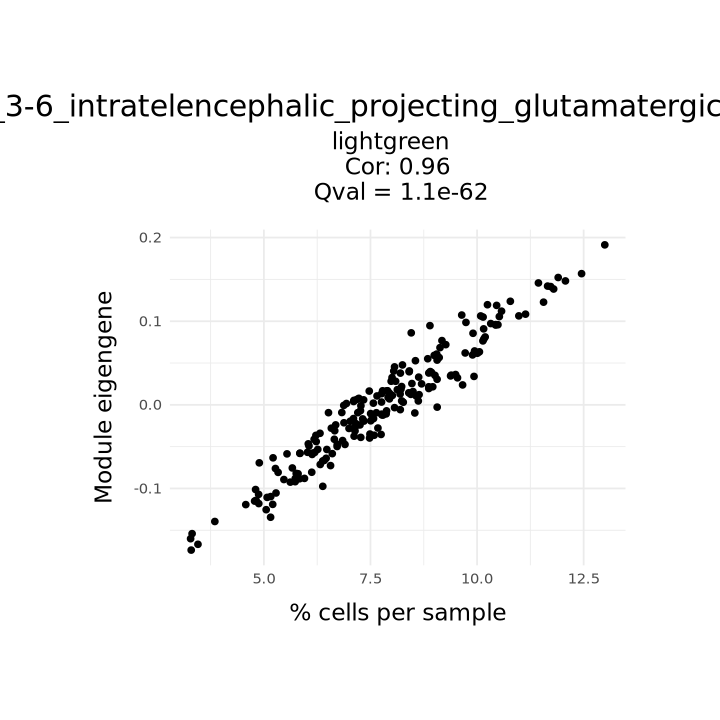

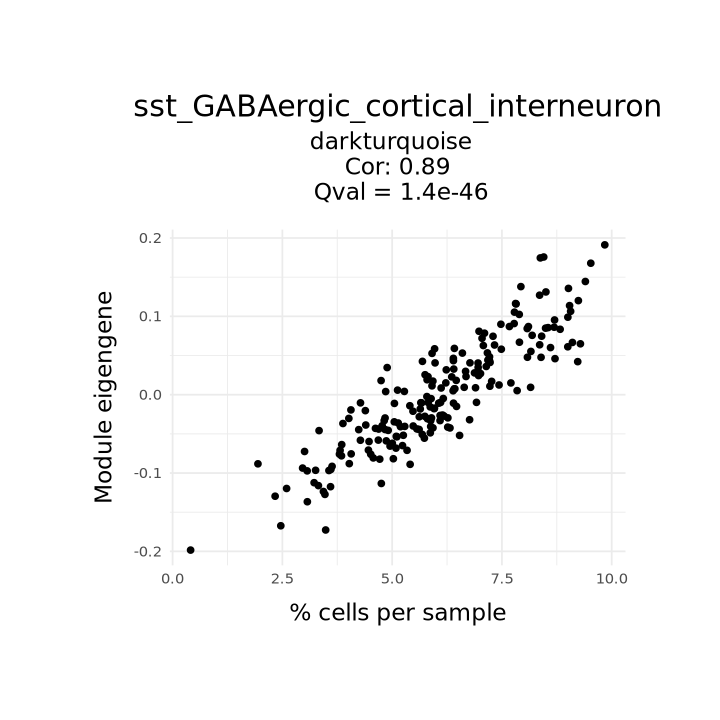

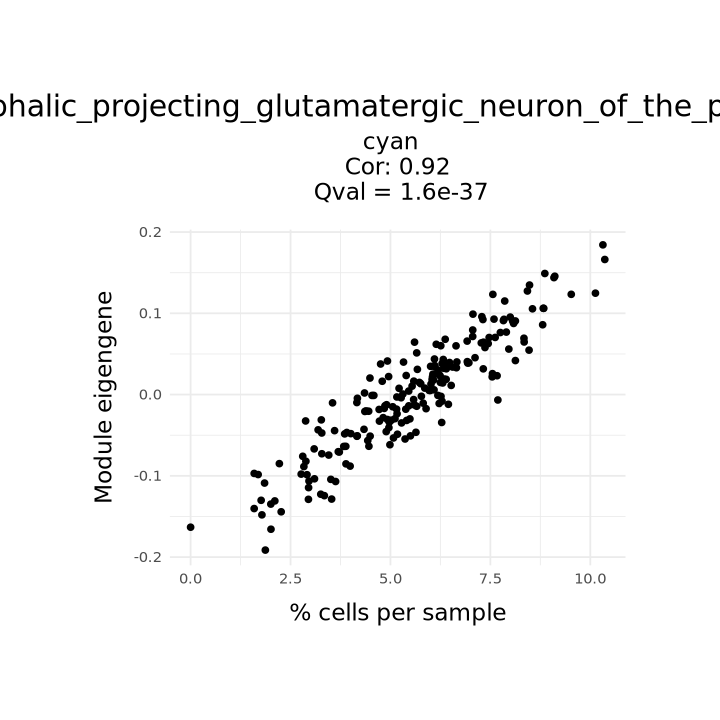

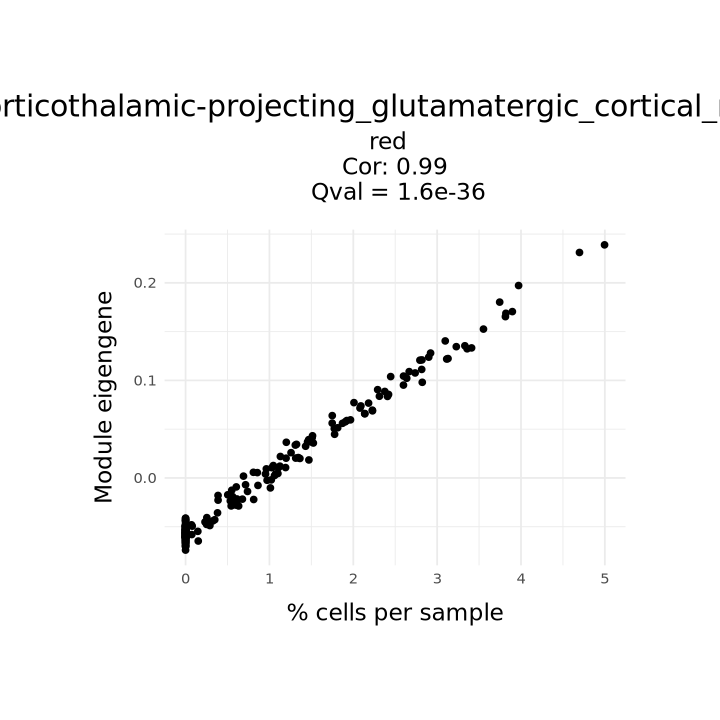

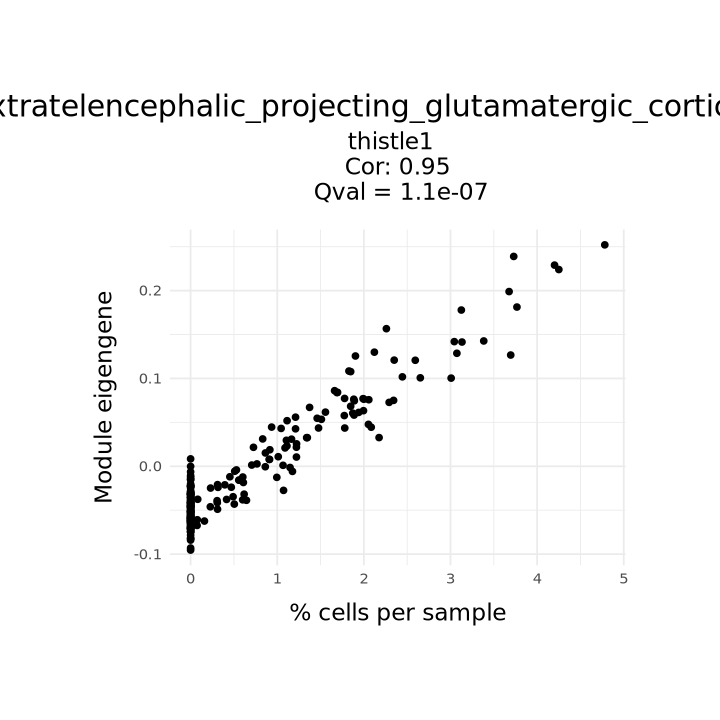

In [11]:
plot_ctype_abundance_vs_top_qval_ME(pseudobulk_legend, top_qval_mods_df)

## Round 2 (SD = 25, mergeParam = 0.95)

In [55]:
network_dir <- "yao_2021_MOp_STAR_SyntheticDataset1_subclass_label_20pcntCells_25SD_200samples_mergeParam0.95_subsetCutoff13.43_Modules"
pseudobulk_legend <- read.csv("data/SyntheticDatasets/SyntheticDataset1_subclass_label_20pcntCells_25SD_200samples_legend_09-27-28.csv")
top_qval_mods_df <- read.csv("data/enrichments/yao_2021_MOp_STAR_SyntheticDataset1_subclass_label_20pcntCells_25SD_200samples_mergeParam0.95_subsetCutoff13.43_Modules_enrichments.csv")

In [56]:
ctype_genes_list <- pairwise_ctype_genes

In [61]:
top_corr_mods_df <- get_top_corr_mods(network_dir, pseudobulk_legend, top_qval_mods_df, ctype_genes_list, mod_def)
top_corr_mods_df %>% arrange(Old_cor)

,Cell_type,Pseudobulk_SD,Cor,Old_cor,Pval,Old_pval,Module_genes,Old_module_genes,DE_genes,Module,Old_module,Network,Old_network,ME_path,Old_ME_path,kME_path,Old_kME_path
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
cadetblue2,L5_IT_CTX,22.93,0.8418582,0.3276489,6.796529e-04,5.340324e-04,"Deptor, Il1rapl2, Dpp4, Colq, Gucy2g, Fam3c, 2810404M03Rik, Lnpk, Tmem232, Foxo1, Cd200r1, Wnt7b, Lamc2, Jaml, NA","Camkk2, Pip4k2c, Ankrd33b, Atmin, Gm48992, Cmc2, Glcci1, Bank1, Clec11a, Colq, Inpp5d, NA, NA, NA, NA","Napb, Colq, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA",cadetblue2,deepskyblue2,Bicor-None_signum0.215_minSize6_merge_ME_0.95_28835,Bicor-None_signum0.582_minSize3_merge_ME_0.95_28835,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/MOp/yao_2021_MOp_STAR_SyntheticDataset1_subclass_label_20pcntCells_25SD_200samples_mergeParam0.95_subsetCutoff13.43_Modules/Bicor-None_signum0.215_minSize6_merge_ME_0.95_28835/Module_eigengenes_12-51-32.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/MOp/yao_2021_MOp_STAR_SyntheticDataset1_subclass_label_20pcntCells_25SD_200samples_mergeParam0.95_subsetCutoff13.43_Modules/Bicor-None_signum0.582_minSize3_merge_ME_0.95_28835/Module_eigengenes_09-55-00.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/MOp/yao_2021_MOp_STAR_SyntheticDataset1_subclass_label_20pcntCells_25SD_200samples_mergeParam0.95_subsetCutoff13.43_Modules/Bicor-None_signum0.215_minSize6_merge_ME_0.95_28835/kME_table_12-51-32.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/MOp/yao_2021_MOp_STAR_SyntheticDataset1_subclass_label_20pcntCells_25SD_200samples_mergeParam0.95_subsetCutoff13.43_Modules/Bicor-None_signum0.582_minSize3_merge_ME_0.95_28835/kME_table_09-55-00.csv
saddlebrown,Sncg,22.88,0.9630678,0.7371081,2.931654e-58,1.303322e-72,"Cnr1, Tnfaip8l3, Plppr1, Yjefn3, Egln3, P2ry1, Frem1, Gm49227, Col14a1, Serpinf1, Jam2, Gsto1, Spx, Serpina3c, Cpne2","Adarb2, Dlx1as, Pnoc, Sema3c, Dlx6os1, Kcnip1, Dlx1, Sp8, Cnr1, Qpct, Gsto1, Nt5dc2, Jam2, Cxcl14, Nrxn3","Cnr1, Elmod1, Ccn3, Nrxn3, Kcnip1, Htr3a, Tnfaip8l3, Gsto1, Gng4, Plppr1, Kctd12, Necab2, Yjefn3, Egln3, Serpinf1",saddlebrown,darkolivegreen,Bicor-None_signum0.215_minSize10_merge_ME_0.95_28835,Bicor-None_signum0.582_minSize10_merge_ME_0.95_28835,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/MOp/yao_2021_MOp_STAR_SyntheticDataset1_subclass_label_20pcntCells_25SD_200samples_mergeParam0.95_subsetCutoff13.43_Modules/Bicor-None_signum0.215_minSize10_merge_ME_0.95_28835/Module_eigengenes_02-11-25.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/MOp/yao_2021_MOp_STAR_SyntheticDataset1_subclass_label_20pcntCells_25SD_200samples_mergeParam0.95_subsetCutoff13.43_Modules/Bicor-None_signum0.582_minSize10_merge_ME_0.95_28835/Module_eigengenes_10-33-48.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/MOp/yao_2021_MOp_STAR_SyntheticDataset1_subclass_label_20pcntCells_25SD_200samples_mergeParam0.95_subsetCutoff13.43_Modules/Bicor-None_signum0.215_minSize10_merge_ME_0.95_28835/kME_table_02-11-25.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/MOp/yao_2021_MOp_STAR_SyntheticDataset1_subclass_label_20pcntCells_25SD_200samples_mergeParam0.95_subsetCutoff13.43_Modules/Bicor-None_signum0.582_minSize10_merge_ME_0.95_28835/kME_table_10-33-48.csv
linen,Pvalb,23.51,0.9388159,0.8434320,1.007315e-29,9.873300e-122,"Pvalb, Nog, Tac1, 6330411D24Rik, Eya4, St3gal6, Gm28501, Lpl, Bcl2l11, Esrrg, Tm6sf1, Cemip, Adamts8, H2-T10, Ddt","Gm13629, Kcnc1, Pvalb, Kcnab3, Cox6a2, Syt2, Flt3, Pacsin2, Nog, Nek7, Ank1, Fndc5, Tac1, Kcnc2, Inpp5j","Pvalb, Tac1, Cplx1, Asns, Sars1, Cox6a2, Kcnc2, Bend6, Ppp1cc, Gabrd, Sncb, Slc38a1, Glrx5, Hcn1, Kcnc1",linen,navajowhite1,Bicor-None_signum0.582_minSize3_merge_ME_0.95_28835,Bicor

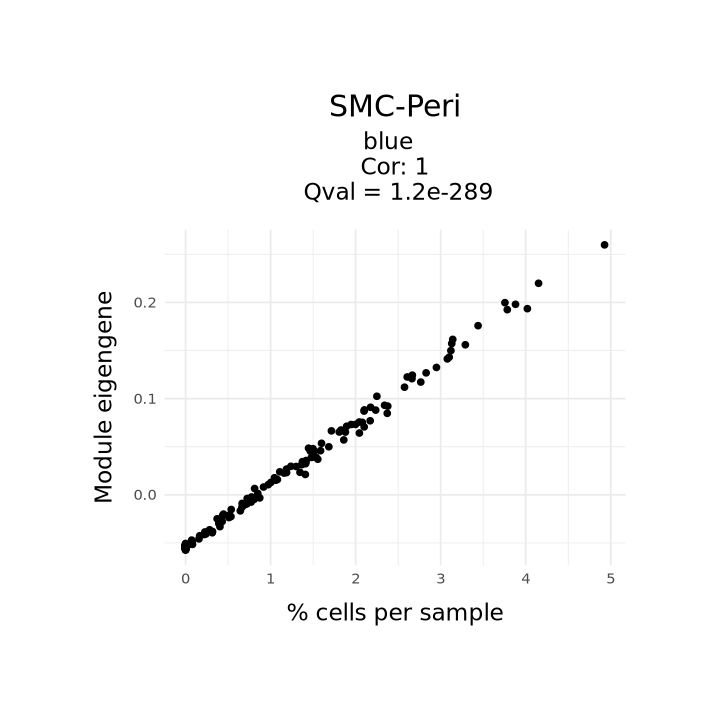

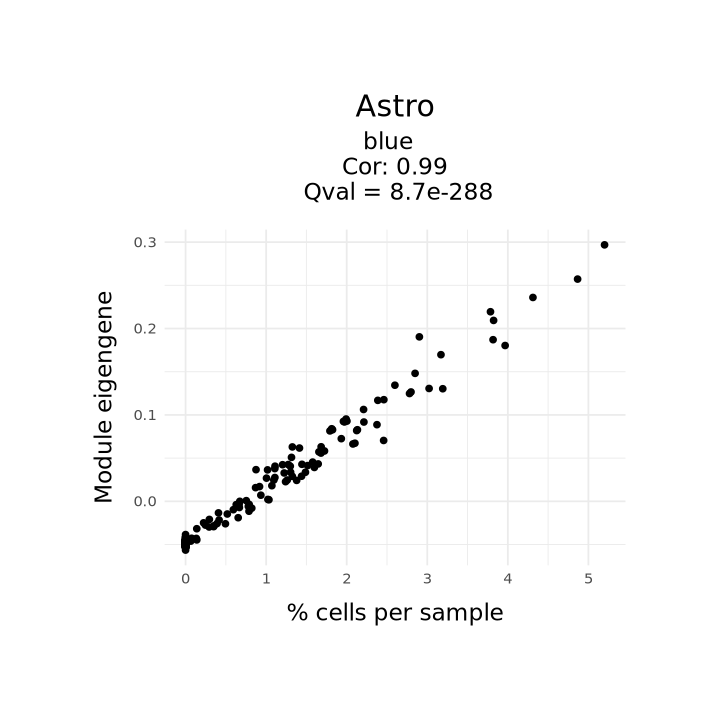

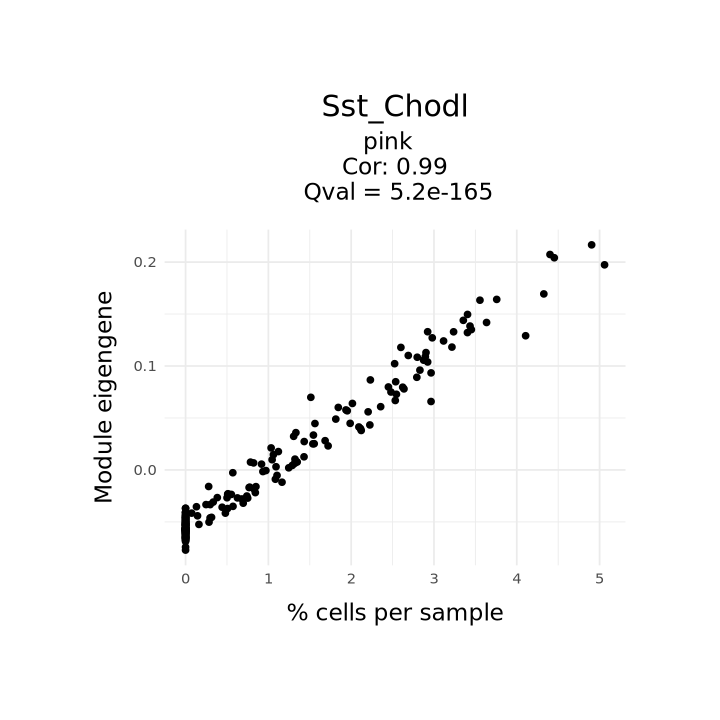

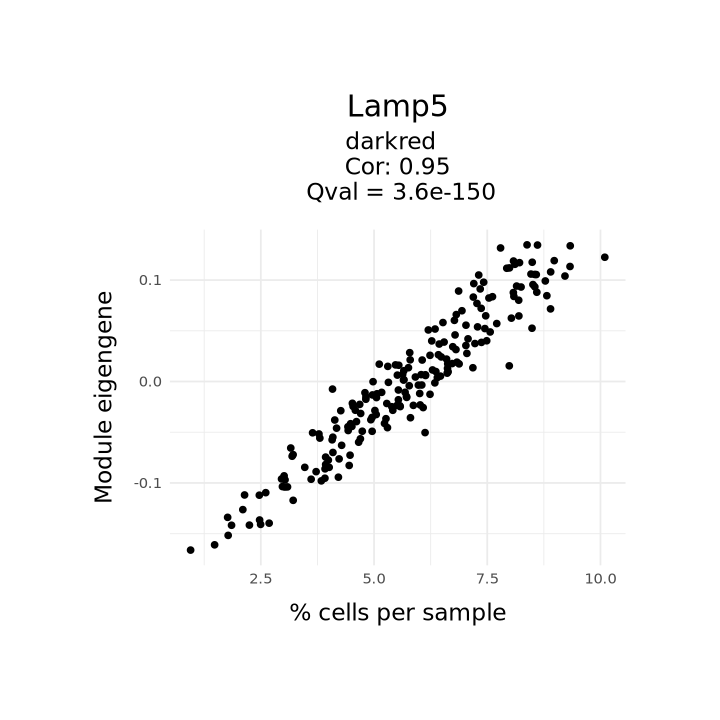

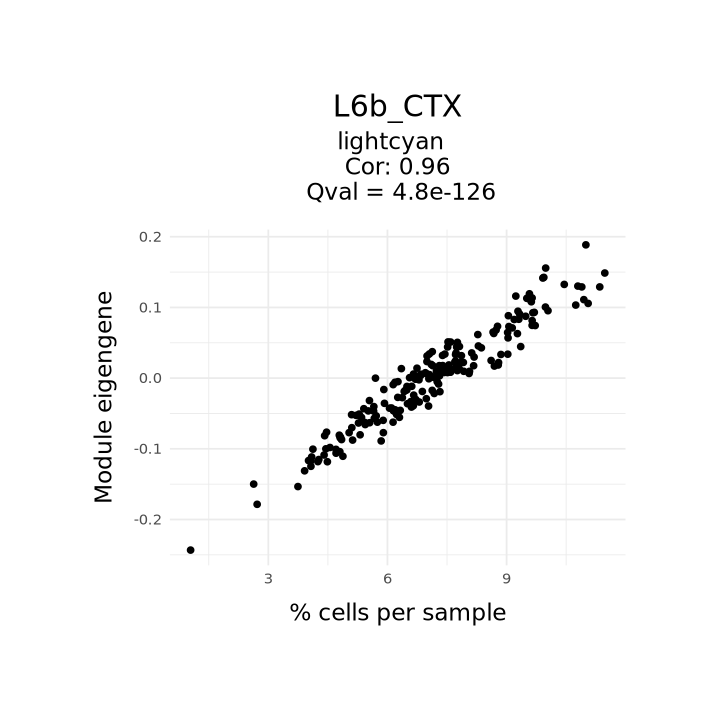

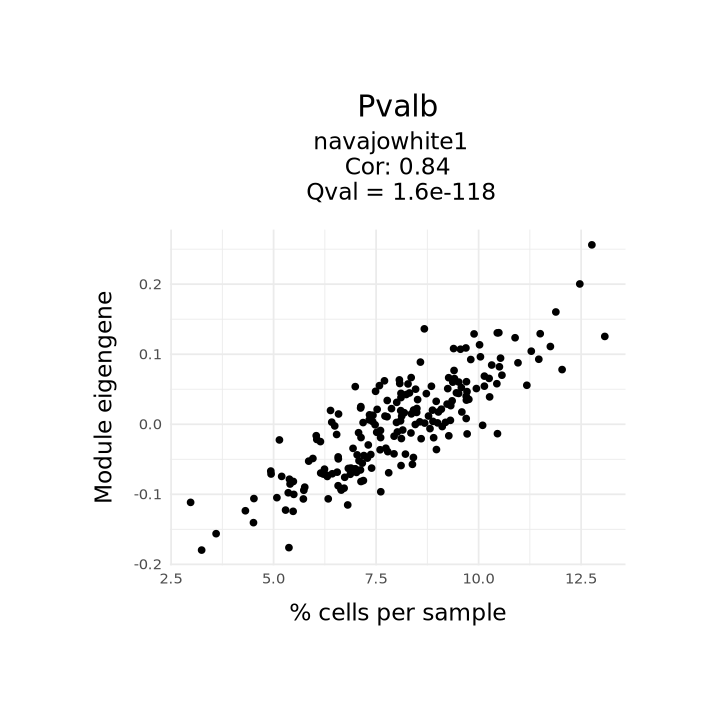

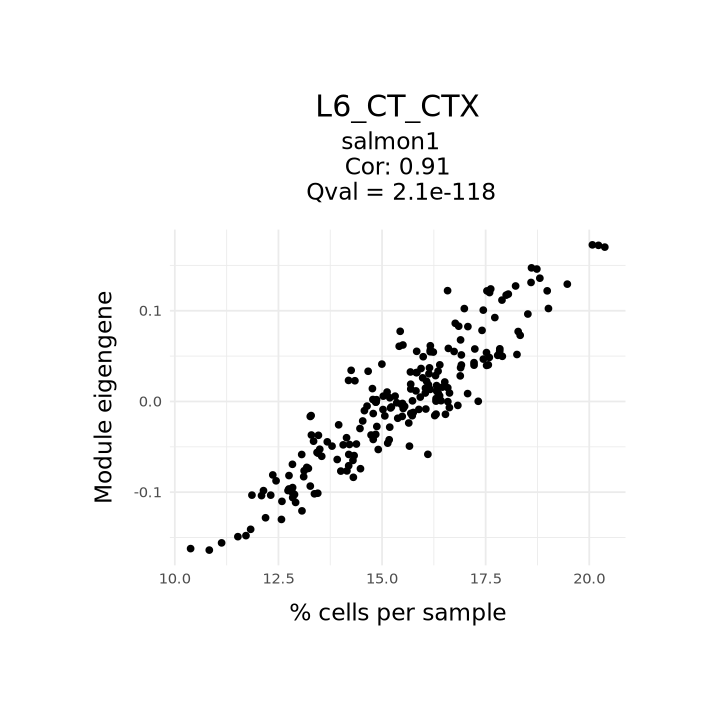

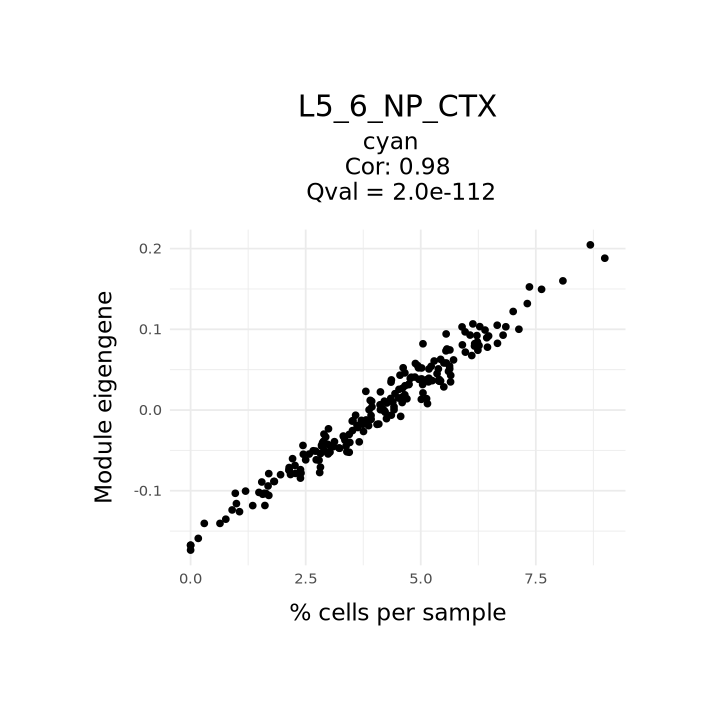

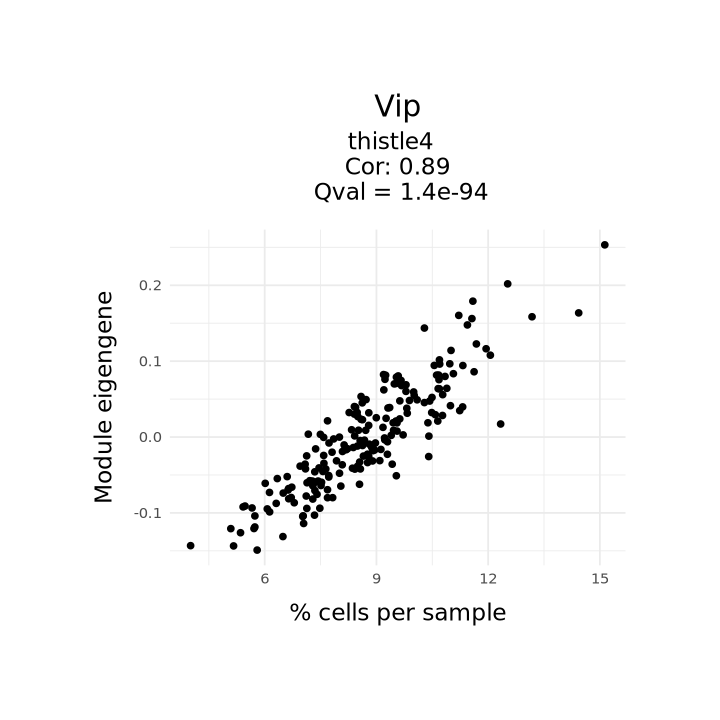

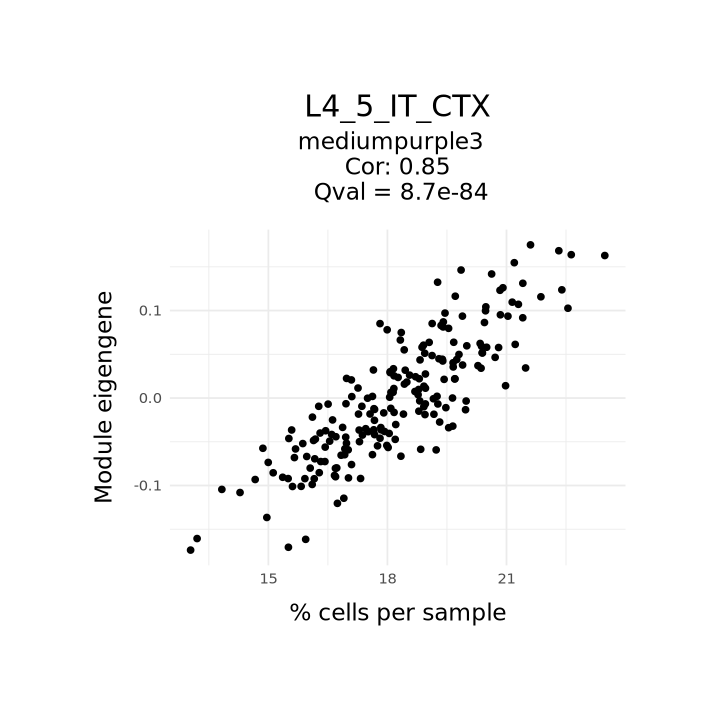

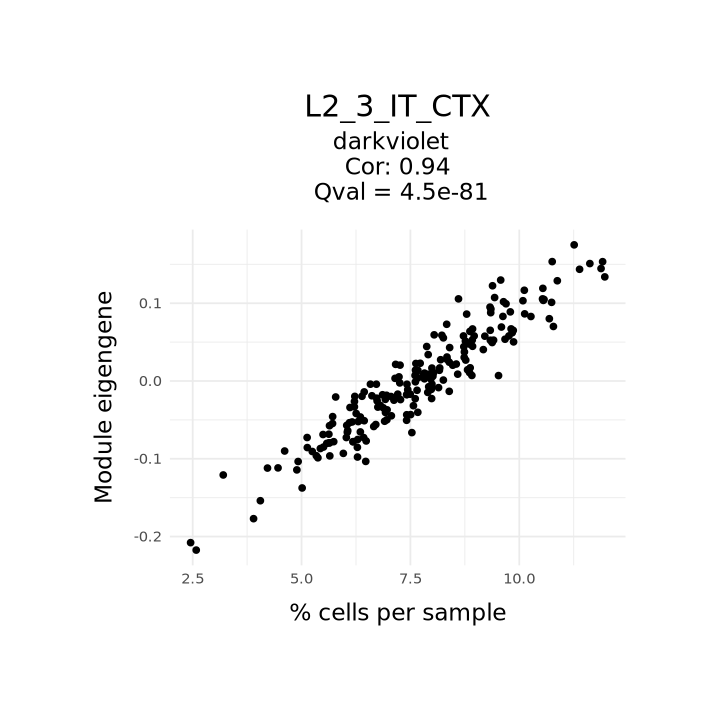

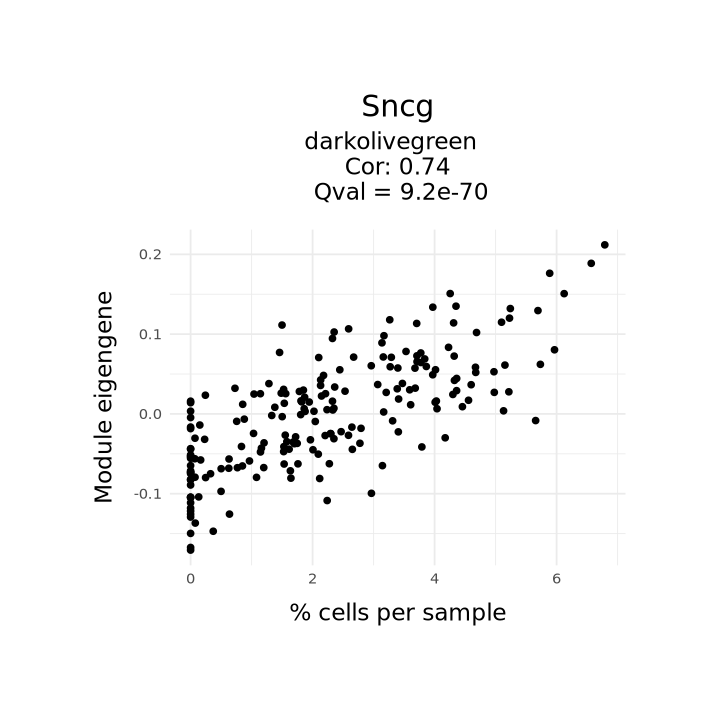

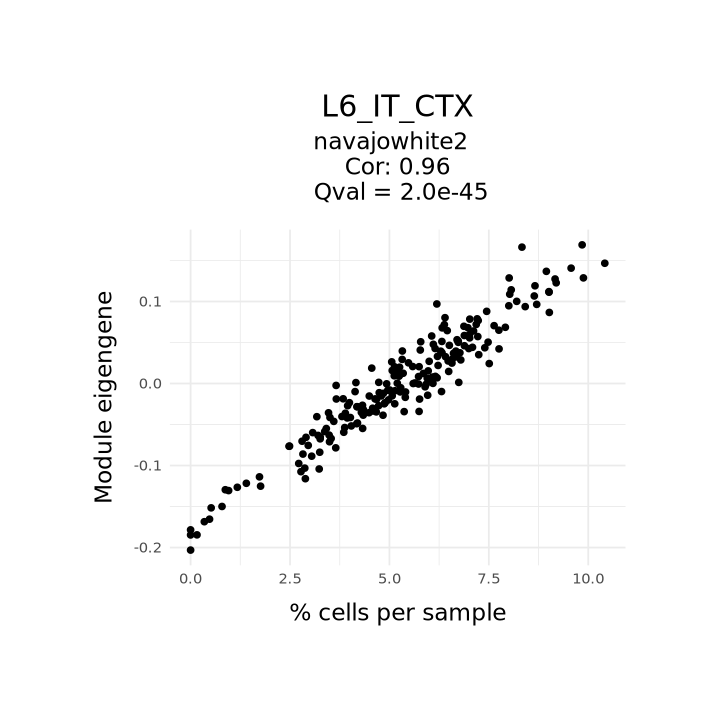

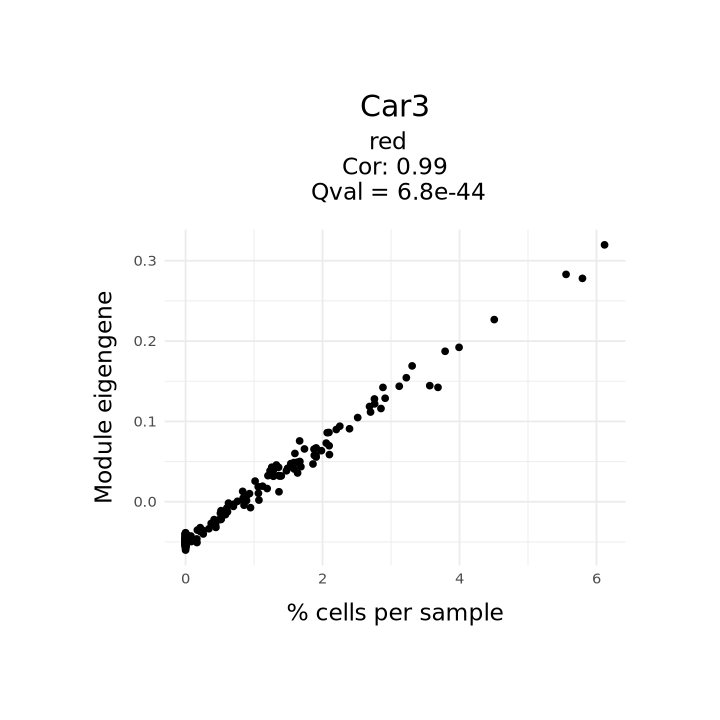

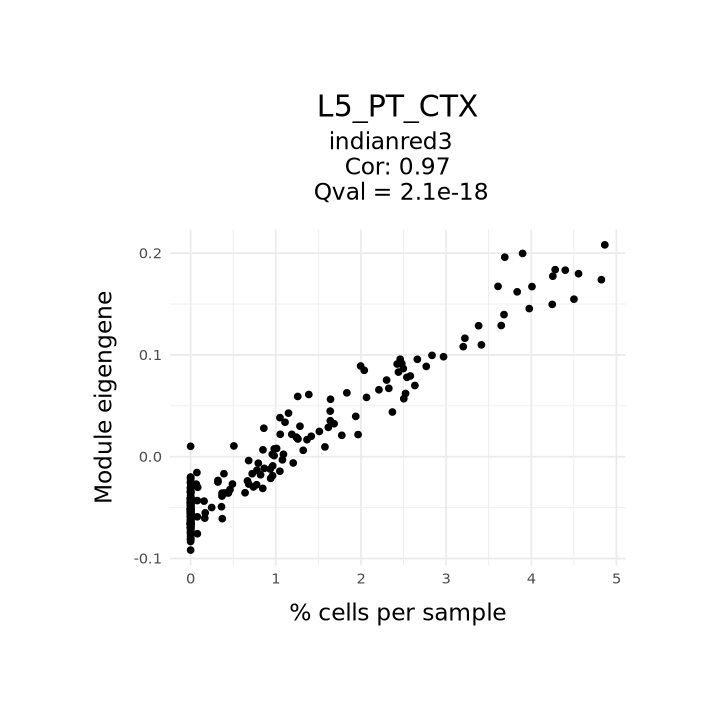

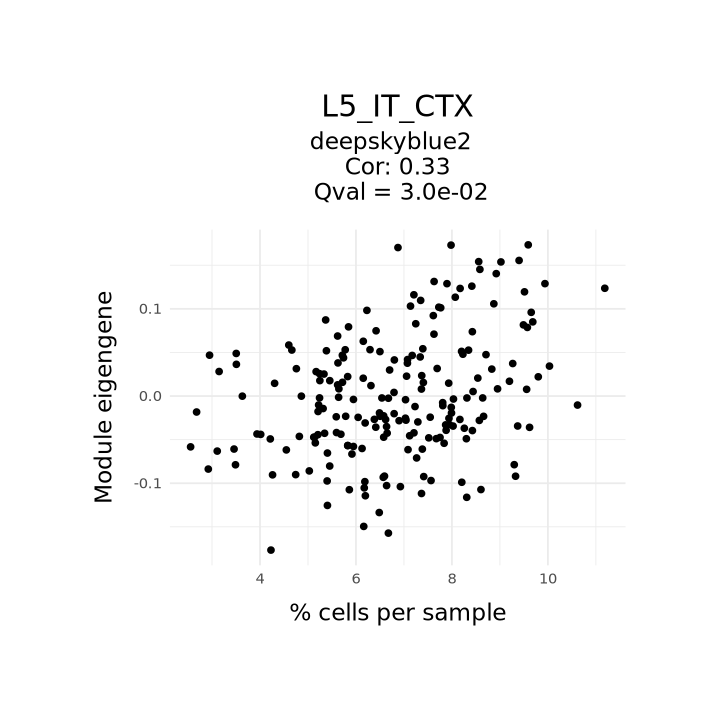

In [62]:
plot_ctype_abundance_vs_top_qval_ME(pseudobulk_legend, top_qval_mods_df)